Paquetes necesarios

In [5]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA 1: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

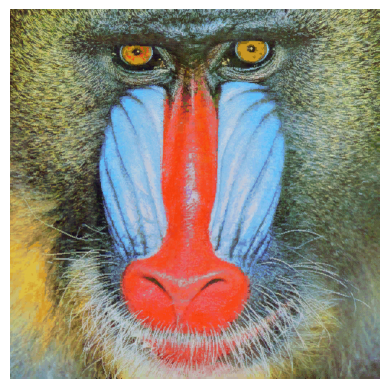

In [7]:
#Lee imagen de archivo
img = cv2.imread('mandril.jpg')

if img is not None:
    # Convierte la imagen a formato RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Muestra la imagen tras convertir a RGB
    plt.axis("off") # Elimina etiquetas de los ejes
    plt.imshow(img_rgb) 
    plt.show()
else: 
    print('Imagen no encontrada')


(0.0, 512.0)

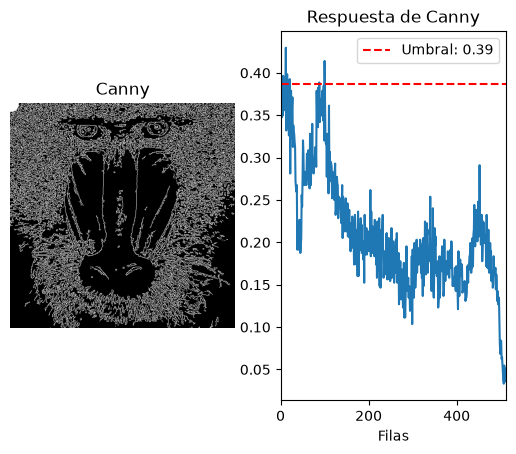

In [ ]:
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)

#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)


#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por fila
rows = row_counts / (255 * canny.shape[0])
max_row = np.max(rows)
umbral = 0.9 * max_row

for x in rows:
    if x[0] >= umbral:
        cv2.circle(canny, (0, int(x[0])), 20, (255, 0, 0), -1) 

#Muestra la imagen
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

#Muestra dicha cuenta gráficamente
plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
plt.axhline(y=umbral, color='r', linestyle='--', label=f'Umbral: {umbral:.2f}')
plt.legend()
#Rango en x definido por las columnas
plt.xlim([0, canny.shape[0]])

